# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibly one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [3]:
import random

class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        if self.rank == "A":
            return 11
        elif self.rank in ["J", "Q", "K"]:
            return 10
        else:
            return int(self.rank)

    def __str__(self):
        return self.rank + " of " + self.suit

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.shown_cards = []
        self.plastic_hit = False
        self.shuffle()

    def build(self):
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        suits = ["Spades", "Hearts", "Diamonds", "Clubs"]
        self.cards = []
        for i in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        self.build()
        random.shuffle(self.cards)
        spot = int(len(self.cards) * random.uniform(0.5, 0.85))
        self.cards.insert(spot, "PLASTIC")
        self.shown_cards = []
        self.plastic_hit = False

    def draw(self):
        card = self.cards.pop(0)
        if card == "PLASTIC":
            self.plastic_hit = True
            card = self.cards.pop(0)
        return card

    def show(self, card):
        self.shown_cards.append(card)

    def cards_left(self):
        count = 0
        for c in self.cards:
            if c != "PLASTIC":
                count += 1
        return count

if __name__ == "__main__":
    deck = Deck(6)
    print("Cards in shoe:", deck.cards_left())

    dealt = 0
    while not deck.plastic_hit:
        card = deck.draw()
        deck.show(card)
        dealt += 1
    print("Plastic card came out after", dealt, "cards")

    deck.shuffle()
    print("After shuffle:", deck.cards_left(), "cards,", len(deck.shown_cards), "shown")

Cards in shoe: 312
Plastic card came out after 178 cards
After shuffle: 312 cards, 0 shown


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [6]:
import random

class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        if self.rank == "A":
            return 11
        elif self.rank in ["J", "Q", "K"]:
            return 10
        else:
            return int(self.rank)

    def __str__(self):
        return self.rank + " of " + self.suit

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.shown_cards = []
        self.plastic_hit = False
        self.shuffle()

    def build(self):
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        suits = ["Spades", "Hearts", "Diamonds", "Clubs"]
        self.cards = []
        for i in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        self.build()
        random.shuffle(self.cards)
        spot = int(len(self.cards) * random.uniform(0.5, 0.85))
        self.cards.insert(spot, "PLASTIC")
        self.shown_cards = []
        self.plastic_hit = False

    def draw(self):
        card = self.cards.pop(0)
        if card == "PLASTIC":
            self.plastic_hit = True
            card = self.cards.pop(0)
        return card

    def show(self, card):
        self.shown_cards.append(card)

    def cards_left(self):
        count = 0
        for c in self.cards:
            if c != "PLASTIC":
                count += 1
        return count

class Hand:
    def __init__(self, bet=0):
        self.cards = []
        self.bet = bet

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_soft(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return aces > 0

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_total() == 21

    def is_bust(self):
        return self.get_total() > 21

    def can_split(self):
        if len(self.cards) != 2:
            return False
        return self.cards[0].get_value() == self.cards[1].get_value()

    def __str__(self):
        names = []
        for card in self.cards:
            names.append(str(card))
        return ", ".join(names) + " (" + str(self.get_total()) + ")"

class Strategy:
    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass

class BasicStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass

class HiLoStrategy(Strategy):
    def __init__(self, min_bet=10, max_bet=100):
        self.min_bet = min_bet
        self.max_bet = max_bet

    def running_count(self, deck):
        pass

    def true_count(self, deck):
        pass

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass

class MimicDealerStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass

class Player:
    def __init__(self, name, chips, strategy):
        self.name = name
        self.chips = chips
        self.hands = []
        self.strategy = strategy

    def place_bet(self, deck):
        pass

    def choose_action(self, hand, upcard, deck):
        pass

    def win(self, amount):
        pass

    def lose(self, amount):
        pass

    def new_round(self):
        pass

class HumanPlayer(Player):
    def place_bet(self, deck):
        pass

    def choose_action(self, hand, upcard, deck):
        pass

class Dealer:
    def __init__(self):
        self.hand = Hand()

    def upcard(self):
        pass

    def must_hit(self):
        pass

    def new_round(self):
        pass

class Game:
    def __init__(self, players, num_decks=6, min_bet=10):
        self.deck = Deck(num_decks)
        self.dealer = Dealer()
        self.players = players
        self.min_bet = min_bet

    def play_round(self):
        pass

    def deal_initial_cards(self):
        pass

    def play_player_turn(self, player):
        pass

    def play_dealer_turn(self):
        pass

    def settle_bets(self):
        pass

    def reshuffle_if_needed(self):
        pass

class Simulation:
    def __init__(self, game, num_rounds):
        self.game = game
        self.num_rounds = num_rounds
        self.results = {}

    def run(self, num_rounds):
        pass

    def avg_winnings_per_hand(self, name):
        pass

    def compare_strategies(self):
        pass

    def print_report(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [7]:
import random

class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        if self.rank == "A":
            return 11
        elif self.rank in ["J", "Q", "K"]:
            return 10
        else:
            return int(self.rank)

    def __str__(self):
        return self.rank + " of " + self.suit

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.shown_cards = []
        self.plastic_hit = False
        self.shuffle()

    def build(self):
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        suits = ["Spades", "Hearts", "Diamonds", "Clubs"]
        self.cards = []
        for i in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        self.build()
        random.shuffle(self.cards)
        spot = int(len(self.cards) * random.uniform(0.5, 0.85))
        self.cards.insert(spot, "PLASTIC")
        self.shown_cards = []
        self.plastic_hit = False

    def draw(self):
        card = self.cards.pop(0)
        if card == "PLASTIC":
            self.plastic_hit = True
            card = self.cards.pop(0)
        return card

    def show(self, card):
        self.shown_cards.append(card)

    def cards_left(self):
        count = 0
        for c in self.cards:
            if c != "PLASTIC":
                count += 1
        return count

class Hand:
    def __init__(self, bet=0):
        self.cards = []
        self.bet = bet
        self.is_split = False

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_soft(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return aces > 0

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_total() == 21 and not self.is_split

    def is_bust(self):
        return self.get_total() > 21

    def can_split(self):
        if len(self.cards) != 2:
            return False
        return self.cards[0].get_value() == self.cards[1].get_value()

    def __str__(self):
        names = []
        for card in self.cards:
            names.append(str(card))
        return ", ".join(names) + " (" + str(self.get_total()) + ")"

class Strategy:
    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass

class BasicStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass

class HiLoStrategy(Strategy):
    def __init__(self, min_bet=10, max_bet=100):
        self.min_bet = min_bet
        self.max_bet = max_bet

    def running_count(self, deck):
        pass

    def true_count(self, deck):
        pass

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass

class MimicDealerStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass

class Player:
    def __init__(self, name, chips, strategy=None):
        self.name = name
        self.chips = chips
        self.hands = []
        self.strategy = strategy
        self.min_bet = 10

    def available_chips(self):
        total_bet = 0
        for hand in self.hands:
            total_bet += hand.bet
        return self.chips - total_bet

    def place_bet(self, deck):
        if self.strategy is None:
            return self.min_bet
        return self.strategy.get_bet(self.chips, deck)

    def choose_action(self, hand, upcard, deck):
        if self.strategy is None:
            return "stand"
        return self.strategy.get_action(hand, upcard, deck)

    def win(self, amount):
        self.chips += amount

    def lose(self, amount):
        self.chips -= amount

    def new_round(self):
        self.hands = []

class HumanPlayer(Player):
    def place_bet(self, deck):
        while True:
            answer = input(self.name + ", you have " + str(self.chips) + " chips. Bet (min " + str(self.min_bet) + "): ")
            try:
                bet = int(answer)
            except ValueError:
                print("Please enter a whole number")
                continue
            if bet < self.min_bet or bet > self.chips:
                print("Bet must be between", self.min_bet, "and", self.chips)
            else:
                return bet

    def choose_action(self, hand, upcard, deck):
        options = {"h": "hit", "s": "stand"}
        if len(hand.cards) == 2 and self.available_chips() >= hand.bet:
            options["d"] = "double"
            if hand.can_split() and len(self.hands) < 4:
                options["p"] = "split"
        print("Dealer shows:", upcard)
        print(self.name + ":", hand)
        prompt = ""
        for key in options:
            prompt += options[key] + " (" + key + ")  "
        while True:
            answer = input(prompt + ": ").strip().lower()
            if answer in options:
                return options[answer]
            print("Please choose one of the options")

class Dealer:
    def __init__(self):
        self.hand = Hand()

    def upcard(self):
        return self.hand.cards[0]

    def must_hit(self):
        return self.hand.get_total() < 17

    def new_round(self):
        self.hand = Hand()

class Game:
    def __init__(self, players, num_decks=6, min_bet=10):
        self.deck = Deck(num_decks)
        self.dealer = Dealer()
        self.players = players
        self.min_bet = min_bet
        for player in self.players:
            player.min_bet = min_bet

    def deal_card(self, hand, face_up=True):
        card = self.deck.draw()
        hand.add_card(card)
        if face_up:
            self.deck.show(card)
        return card

    def show_table(self, hide_dealer=True):
        print()
        if hide_dealer:
            print("Dealer shows:", self.dealer.upcard())
        else:
            print("Dealer:", self.dealer.hand)
        for player in self.players:
            for hand in player.hands:
                print(player.name + " (bet " + str(hand.bet) + "):", hand)
        print()

    def play_round(self):
        self.reshuffle_if_needed()
        self.dealer.new_round()
        playing = []
        for player in self.players:
            player.new_round()
            if player.chips >= self.min_bet:
                bet = player.place_bet(self.deck)
                player.hands.append(Hand(bet))
                playing.append(player)
        if len(playing) == 0:
            print("No players have enough chips to play")
            return
        self.deal_initial_cards()
        self.show_table()
        if self.dealer.hand.is_blackjack():
            self.deck.show(self.dealer.hand.cards[1])
            print("Dealer has blackjack!")
        else:
            for player in playing:
                self.play_player_turn(player)
            live = False
            for player in playing:
                for hand in player.hands:
                    if not hand.is_bust() and not hand.is_blackjack():
                        live = True
            if live:
                self.play_dealer_turn()
            else:
                self.deck.show(self.dealer.hand.cards[1])
        self.show_table(hide_dealer=False)
        self.settle_bets()

    def deal_initial_cards(self):
        for i in range(2):
            for player in self.players:
                for hand in player.hands:
                    self.deal_card(hand)
            self.deal_card(self.dealer.hand, face_up=(i == 0))

    def play_player_turn(self, player):
        i = 0
        while i < len(player.hands):
            hand = player.hands[i]
            while not hand.is_bust() and hand.get_total() < 21:
                action = player.choose_action(hand, self.dealer.upcard(), self.deck)
                if action == "hit":
                    self.deal_card(hand)
                    print(player.name + " hits:", hand)
                elif action == "double" and len(hand.cards) == 2 and player.available_chips() >= hand.bet:
                    hand.bet *= 2
                    self.deal_card(hand)
                    print(player.name + " doubles:", hand)
                    break
                elif action == "split" and hand.can_split() and player.available_chips() >= hand.bet and len(player.hands) < 4:
                    new_hand = Hand(hand.bet)
                    new_hand.add_card(hand.cards.pop())
                    hand.is_split = True
                    new_hand.is_split = True
                    self.deal_card(hand)
                    self.deal_card(new_hand)
                    player.hands.insert(i + 1, new_hand)
                    print(player.name + " splits:", hand)
                else:
                    break
            i += 1

    def play_dealer_turn(self):
        self.deck.show(self.dealer.hand.cards[1])
        while self.dealer.must_hit():
            self.deal_card(self.dealer.hand)

    def settle_bets(self):
        dealer_hand = self.dealer.hand
        for player in self.players:
            for hand in player.hands:
                if hand.is_bust():
                    player.lose(hand.bet)
                    result = "busts and loses " + str(hand.bet)
                elif hand.is_blackjack() and not dealer_hand.is_blackjack():
                    player.win(hand.bet * 1.5)
                    result = "has blackjack and wins " + str(hand.bet * 1.5)
                elif hand.is_blackjack():
                    result = "pushes"
                elif dealer_hand.is_blackjack():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet) + " to dealer blackjack"
                elif dealer_hand.is_bust():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet) + " (dealer busts)"
                elif hand.get_total() > dealer_hand.get_total():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet)
                elif hand.get_total() < dealer_hand.get_total():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet)
                else:
                    result = "pushes"
                print(player.name + ":", result, "- chips:", player.chips)

    def reshuffle_if_needed(self):
        if self.deck.plastic_hit:
            print("Plastic card was dealt, shuffling the shoe")
            self.deck.shuffle()

class Simulation:
    def __init__(self, game, num_rounds):
        self.game = game
        self.num_rounds = num_rounds
        self.results = {}

    def run(self, num_rounds):
        pass

    def avg_winnings_per_hand(self, name):
        pass

    def compare_strategies(self):
        pass

    def print_report(self):
        pass

game = Game([HumanPlayer("You", 500)])

while True:
    game.play_round()
    if game.players[0].chips < game.min_bet:
        print("You are out of chips")
        break
    again = input("Play another round? (y/n): ")
    if again.strip().lower() != "y":
        break

You, you have 500 chips. Bet (min 10):  50



Dealer shows: 6 of Clubs
You (bet 50): 7 of Diamonds, 2 of Diamonds (9)

Dealer shows: 6 of Clubs
You: 7 of Diamonds, 2 of Diamonds (9)


hit (h)  stand (s)  double (d)  :  d


You doubles: 7 of Diamonds, 2 of Diamonds, 6 of Hearts (15)

Dealer: 6 of Clubs, 9 of Hearts, 6 of Diamonds (21)
You (bet 100): 7 of Diamonds, 2 of Diamonds, 6 of Hearts (15)

You: loses 100 - chips: 400


Play another round? (y/n):  n


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [9]:
import random


class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        if self.rank == "A":
            return 11
        elif self.rank in ["J", "Q", "K"]:
            return 10
        else:
            return int(self.rank)

    def __str__(self):
        return self.rank + " of " + self.suit


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.shown_cards = []
        self.plastic_hit = False
        self.shuffle()

    def build(self):
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        suits = ["Spades", "Hearts", "Diamonds", "Clubs"]
        self.cards = []
        for i in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        self.build()
        random.shuffle(self.cards)
        spot = int(len(self.cards) * random.uniform(0.5, 0.85))
        self.cards.insert(spot, "PLASTIC")
        self.shown_cards = []
        self.plastic_hit = False

    def draw(self):
        card = self.cards.pop(0)
        if card == "PLASTIC":
            self.plastic_hit = True
            card = self.cards.pop(0)
        return card

    def show(self, card):
        self.shown_cards.append(card)

    def cards_left(self):
        count = 0
        for c in self.cards:
            if c != "PLASTIC":
                count += 1
        return count


class Hand:
    def __init__(self, bet=0):
        self.cards = []
        self.bet = bet
        self.is_split = False

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_soft(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return aces > 0

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_total() == 21 and not self.is_split

    def is_bust(self):
        return self.get_total() > 21

    def can_split(self):
        if len(self.cards) != 2:
            return False
        return self.cards[0].get_value() == self.cards[1].get_value()

    def __str__(self):
        names = []
        for card in self.cards:
            names.append(str(card))
        return ", ".join(names) + " (" + str(self.get_total()) + ")"


class Strategy:
    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class BasicStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class HiLoStrategy(Strategy):
    def __init__(self, min_bet=10, max_bet=100):
        self.min_bet = min_bet
        self.max_bet = max_bet

    def running_count(self, deck):
        pass

    def true_count(self, deck):
        pass

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class MimicDealerStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        if hand.get_total() < 17:
            return "hit"
        return "stand"


class Player:
    def __init__(self, name, chips, strategy=None):
        self.name = name
        self.chips = chips
        self.hands = []
        self.strategy = strategy
        self.min_bet = 10

    def available_chips(self):
        total_bet = 0
        for hand in self.hands:
            total_bet += hand.bet
        return self.chips - total_bet

    def place_bet(self, deck):
        if self.strategy is None:
            return self.min_bet
        return self.strategy.get_bet(self.chips, deck)

    def choose_action(self, hand, upcard, deck):
        if self.strategy is None:
            return "stand"
        return self.strategy.get_action(hand, upcard, deck)

    def win(self, amount):
        self.chips += amount

    def lose(self, amount):
        self.chips -= amount

    def new_round(self):
        self.hands = []


class HumanPlayer(Player):
    def place_bet(self, deck):
        while True:
            answer = input(self.name + ", you have " + str(self.chips) + " chips. Bet (min " + str(self.min_bet) + "): ")
            try:
                bet = int(answer)
            except ValueError:
                print("Please enter a whole number")
                continue
            if bet < self.min_bet or bet > self.chips:
                print("Bet must be between", self.min_bet, "and", self.chips)
            else:
                return bet

    def choose_action(self, hand, upcard, deck):
        options = {"h": "hit", "s": "stand"}
        if len(hand.cards) == 2 and self.available_chips() >= hand.bet:
            options["d"] = "double"
            if hand.can_split() and len(self.hands) < 4:
                options["p"] = "split"
        print("Dealer shows:", upcard)
        print(self.name + ":", hand)
        prompt = ""
        for key in options:
            prompt += options[key] + " (" + key + ")  "
        while True:
            answer = input(prompt + ": ").strip().lower()
            if answer in options:
                return options[answer]
            print("Please choose one of the options")


class Dealer:
    def __init__(self):
        self.hand = Hand()

    def upcard(self):
        return self.hand.cards[0]

    def must_hit(self):
        return self.hand.get_total() < 17

    def new_round(self):
        self.hand = Hand()


class Game:
    def __init__(self, players, num_decks=6, min_bet=10):
        self.deck = Deck(num_decks)
        self.dealer = Dealer()
        self.players = players
        self.min_bet = min_bet
        self.verbose = True
        self.shuffles = 0
        for player in self.players:
            player.min_bet = min_bet

    def say(self, *words):
        if self.verbose:
            print(*words)

    def deal_card(self, hand, face_up=True):
        card = self.deck.draw()
        hand.add_card(card)
        if face_up:
            self.deck.show(card)
        return card

    def show_table(self, hide_dealer=True):
        self.say()
        if hide_dealer:
            self.say("Dealer shows:", self.dealer.upcard())
        else:
            self.say("Dealer:", self.dealer.hand)
        for player in self.players:
            for hand in player.hands:
                self.say(player.name + " (bet " + str(hand.bet) + "):", hand)
        self.say()

    def play_round(self):
        self.reshuffle_if_needed()
        self.dealer.new_round()
        playing = []
        for player in self.players:
            player.new_round()
            if player.chips >= self.min_bet:
                bet = player.place_bet(self.deck)
                player.hands.append(Hand(bet))
                playing.append(player)
        if len(playing) == 0:
            self.say("No players have enough chips to play")
            return
        self.deal_initial_cards()
        self.show_table()
        if self.dealer.hand.is_blackjack():
            self.deck.show(self.dealer.hand.cards[1])
            self.say("Dealer has blackjack!")
        else:
            for player in playing:
                self.play_player_turn(player)
            live = False
            for player in playing:
                for hand in player.hands:
                    if not hand.is_bust() and not hand.is_blackjack():
                        live = True
            if live:
                self.play_dealer_turn()
            else:
                self.deck.show(self.dealer.hand.cards[1])
        self.show_table(hide_dealer=False)
        self.settle_bets()

    def deal_initial_cards(self):
        for i in range(2):
            for player in self.players:
                for hand in player.hands:
                    self.deal_card(hand)
            self.deal_card(self.dealer.hand, face_up=(i == 0))

    def play_player_turn(self, player):
        i = 0
        while i < len(player.hands):
            hand = player.hands[i]
            while not hand.is_bust() and hand.get_total() < 21:
                action = player.choose_action(hand, self.dealer.upcard(), self.deck)
                if action == "hit":
                    self.deal_card(hand)
                    self.say(player.name + " hits:", hand)
                elif action == "double" and len(hand.cards) == 2 and player.available_chips() >= hand.bet:
                    hand.bet *= 2
                    self.deal_card(hand)
                    self.say(player.name + " doubles:", hand)
                    break
                elif action == "split" and hand.can_split() and player.available_chips() >= hand.bet and len(player.hands) < 4:
                    new_hand = Hand(hand.bet)
                    new_hand.add_card(hand.cards.pop())
                    hand.is_split = True
                    new_hand.is_split = True
                    self.deal_card(hand)
                    self.deal_card(new_hand)
                    player.hands.insert(i + 1, new_hand)
                    self.say(player.name + " splits:", hand)
                else:
                    break
            i += 1

    def play_dealer_turn(self):
        self.deck.show(self.dealer.hand.cards[1])
        while self.dealer.must_hit():
            self.deal_card(self.dealer.hand)

    def settle_bets(self):
        dealer_hand = self.dealer.hand
        for player in self.players:
            for hand in player.hands:
                if hand.is_bust():
                    player.lose(hand.bet)
                    result = "busts and loses " + str(hand.bet)
                elif hand.is_blackjack() and not dealer_hand.is_blackjack():
                    player.win(hand.bet * 1.5)
                    result = "has blackjack and wins " + str(hand.bet * 1.5)
                elif hand.is_blackjack():
                    result = "pushes"
                elif dealer_hand.is_blackjack():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet) + " to dealer blackjack"
                elif dealer_hand.is_bust():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet) + " (dealer busts)"
                elif hand.get_total() > dealer_hand.get_total():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet)
                elif hand.get_total() < dealer_hand.get_total():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet)
                else:
                    result = "pushes"
                self.say(player.name + ":", result, "- chips:", player.chips)

    def reshuffle_if_needed(self):
        if self.deck.plastic_hit:
            self.say("Plastic card was dealt, shuffling the shoe")
            self.deck.shuffle()
            self.shuffles += 1


class Simulation:
    def __init__(self, game, num_rounds):
        self.game = game
        self.num_rounds = num_rounds
        self.results = {}

    def run(self, num_rounds):
        pass

    def avg_winnings_per_hand(self, name):
        pass

    def compare_strategies(self):
        pass

    def print_report(self):
        pass


import random
random.seed(42)

ann = Player("Ann", 500, MimicDealerStrategy(10))
bob = Player("Bob", 500, MimicDealerStrategy(25))
cat = Player("Cat", 500, MimicDealerStrategy(50))
game = Game([ann, bob, cat])

for i in range(5):
    print("ROUND", i + 1)
    game.play_round()


for player in game.players:
    print(player.name, "has", player.chips, "chips")
print("Cards shown:", len(game.deck.shown_cards))
print("Cards left:", game.deck.cards_left())


random.seed(7)
ann = Player("Ann", 100000, MimicDealerStrategy(10))
bob = Player("Bob", 100000, MimicDealerStrategy(25))
cat = Player("Cat", 100000, MimicDealerStrategy(50))
big_game = Game([ann, bob, cat])
big_game.verbose = False

for i in range(2000):
    big_game.play_round()

print("Rounds played: 2000")
print("Times shuffled:", big_game.shuffles)
for player in big_game.players:
    print(player.name, "ended with", player.chips, "chips")
    print("average per round:", (player.chips - 100000) / 2000)

ROUND 1

Dealer shows: 8 of Hearts
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds (8)

Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades (11)
Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Dealer: 8 of Hearts, 4 of Clubs, K of Diamonds (22)
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Ann: wins 10 (dealer busts) - chips: 510
Bob: wins 25 (dealer busts) - chips: 525
Cat: wins 50 (dealer busts) - chips: 550
ROUND 2

Dealer shows: 6 of Diamonds
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 of Diamonds (16)
Cat (bet 50): 10 of Clubs, Q of Clubs (20)

Bob hits: 8 of Spades, 8 of Diamonds, 4 of Diamonds (20)

Dealer: 6 of Diamonds, 2 of Spades, 3 of Spades, 9 of Hearts (20)
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 o

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [10]:
import random


class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        if self.rank == "A":
            return 11
        elif self.rank in ["J", "Q", "K"]:
            return 10
        else:
            return int(self.rank)

    def __str__(self):
        return self.rank + " of " + self.suit


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.shown_cards = []
        self.plastic_hit = False
        self.shuffle()

    def build(self):
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        suits = ["Spades", "Hearts", "Diamonds", "Clubs"]
        self.cards = []
        for i in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        self.build()
        random.shuffle(self.cards)
        spot = int(len(self.cards) * random.uniform(0.5, 0.85))
        self.cards.insert(spot, "PLASTIC")
        self.shown_cards = []
        self.plastic_hit = False

    def draw(self):
        card = self.cards.pop(0)
        if card == "PLASTIC":
            self.plastic_hit = True
            card = self.cards.pop(0)
        return card

    def show(self, card):
        self.shown_cards.append(card)

    def cards_left(self):
        count = 0
        for c in self.cards:
            if c != "PLASTIC":
                count += 1
        return count


class Hand:
    def __init__(self, bet=0):
        self.cards = []
        self.bet = bet
        self.is_split = False

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_soft(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return aces > 0

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_total() == 21 and not self.is_split

    def is_bust(self):
        return self.get_total() > 21

    def can_split(self):
        if len(self.cards) != 2:
            return False
        return self.cards[0].get_value() == self.cards[1].get_value()

    def __str__(self):
        names = []
        for card in self.cards:
            names.append(str(card))
        return ", ".join(names) + " (" + str(self.get_total()) + ")"


class Strategy:
    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class BasicStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class HiLoStrategy(Strategy):
    def __init__(self, flat_bet=10, threshold=0):
        self.flat_bet = flat_bet
        self.threshold = threshold

    def running_count(self, deck):
        count = 0
        for card in deck.shown_cards:
            if card.get_value() <= 6:
                count += 1
            elif card.get_value() >= 10:
                count -= 1
        return count

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        total = hand.get_total()
        if total < 12:
            return "hit"
        if total >= 17:
            return "stand"
        if self.running_count(deck) < self.threshold:
            return "hit"
        return "stand"


class MimicDealerStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        if hand.get_total() < 17:
            return "hit"
        return "stand"


class Player:
    def __init__(self, name, chips, strategy=None):
        self.name = name
        self.chips = chips
        self.hands = []
        self.strategy = strategy
        self.min_bet = 10

    def available_chips(self):
        total_bet = 0
        for hand in self.hands:
            total_bet += hand.bet
        return self.chips - total_bet

    def place_bet(self, deck):
        if self.strategy is None:
            return self.min_bet
        return self.strategy.get_bet(self.chips, deck)

    def choose_action(self, hand, upcard, deck):
        if self.strategy is None:
            return "stand"
        return self.strategy.get_action(hand, upcard, deck)

    def win(self, amount):
        self.chips += amount

    def lose(self, amount):
        self.chips -= amount

    def new_round(self):
        self.hands = []


class HumanPlayer(Player):
    def place_bet(self, deck):
        while True:
            answer = input(self.name + ", you have " + str(self.chips) + " chips. Bet (min " + str(self.min_bet) + "): ")
            try:
                bet = int(answer)
            except ValueError:
                print("Please enter a whole number")
                continue
            if bet < self.min_bet or bet > self.chips:
                print("Bet must be between", self.min_bet, "and", self.chips)
            else:
                return bet

    def choose_action(self, hand, upcard, deck):
        options = {"h": "hit", "s": "stand"}
        if len(hand.cards) == 2 and self.available_chips() >= hand.bet:
            options["d"] = "double"
            if hand.can_split() and len(self.hands) < 4:
                options["p"] = "split"
        print("Dealer shows:", upcard)
        print(self.name + ":", hand)
        prompt = ""
        for key in options:
            prompt += options[key] + " (" + key + ")  "
        while True:
            answer = input(prompt + ": ").strip().lower()
            if answer in options:
                return options[answer]
            print("Please choose one of the options")


class Dealer:
    def __init__(self):
        self.hand = Hand()

    def upcard(self):
        return self.hand.cards[0]

    def must_hit(self):
        return self.hand.get_total() < 17

    def new_round(self):
        self.hand = Hand()


class Game:
    def __init__(self, players, num_decks=6, min_bet=10):
        self.deck = Deck(num_decks)
        self.dealer = Dealer()
        self.players = players
        self.min_bet = min_bet
        self.verbose = True
        self.shuffles = 0
        for player in self.players:
            player.min_bet = min_bet

    def say(self, *words):
        if self.verbose:
            print(*words)

    def deal_card(self, hand, face_up=True):
        card = self.deck.draw()
        hand.add_card(card)
        if face_up:
            self.deck.show(card)
        return card

    def show_table(self, hide_dealer=True):
        self.say()
        if hide_dealer:
            self.say("Dealer shows:", self.dealer.upcard())
        else:
            self.say("Dealer:", self.dealer.hand)
        for player in self.players:
            for hand in player.hands:
                self.say(player.name + " (bet " + str(hand.bet) + "):", hand)
        self.say()

    def play_round(self):
        self.reshuffle_if_needed()
        self.dealer.new_round()
        playing = []
        for player in self.players:
            player.new_round()
            if player.chips >= self.min_bet:
                bet = player.place_bet(self.deck)
                player.hands.append(Hand(bet))
                playing.append(player)
        if len(playing) == 0:
            self.say("No players have enough chips to play")
            return
        self.deal_initial_cards()
        self.show_table()
        if self.dealer.hand.is_blackjack():
            self.deck.show(self.dealer.hand.cards[1])
            self.say("Dealer has blackjack!")
        else:
            for player in playing:
                self.play_player_turn(player)
            live = False
            for player in playing:
                for hand in player.hands:
                    if not hand.is_bust() and not hand.is_blackjack():
                        live = True
            if live:
                self.play_dealer_turn()
            else:
                self.deck.show(self.dealer.hand.cards[1])
        self.show_table(hide_dealer=False)
        self.settle_bets()

    def deal_initial_cards(self):
        for i in range(2):
            for player in self.players:
                for hand in player.hands:
                    self.deal_card(hand)
            self.deal_card(self.dealer.hand, face_up=(i == 0))

    def play_player_turn(self, player):
        i = 0
        while i < len(player.hands):
            hand = player.hands[i]
            while not hand.is_bust() and hand.get_total() < 21:
                action = player.choose_action(hand, self.dealer.upcard(), self.deck)
                if action == "hit":
                    self.deal_card(hand)
                    self.say(player.name + " hits:", hand)
                elif action == "double" and len(hand.cards) == 2 and player.available_chips() >= hand.bet:
                    hand.bet *= 2
                    self.deal_card(hand)
                    self.say(player.name + " doubles:", hand)
                    break
                elif action == "split" and hand.can_split() and player.available_chips() >= hand.bet and len(player.hands) < 4:
                    new_hand = Hand(hand.bet)
                    new_hand.add_card(hand.cards.pop())
                    hand.is_split = True
                    new_hand.is_split = True
                    self.deal_card(hand)
                    self.deal_card(new_hand)
                    player.hands.insert(i + 1, new_hand)
                    self.say(player.name + " splits:", hand)
                else:
                    break
            i += 1

    def play_dealer_turn(self):
        self.deck.show(self.dealer.hand.cards[1])
        while self.dealer.must_hit():
            self.deal_card(self.dealer.hand)

    def settle_bets(self):
        dealer_hand = self.dealer.hand
        for player in self.players:
            for hand in player.hands:
                if hand.is_bust():
                    player.lose(hand.bet)
                    result = "busts and loses " + str(hand.bet)
                elif hand.is_blackjack() and not dealer_hand.is_blackjack():
                    player.win(hand.bet * 1.5)
                    result = "has blackjack and wins " + str(hand.bet * 1.5)
                elif hand.is_blackjack():
                    result = "pushes"
                elif dealer_hand.is_blackjack():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet) + " to dealer blackjack"
                elif dealer_hand.is_bust():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet) + " (dealer busts)"
                elif hand.get_total() > dealer_hand.get_total():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet)
                elif hand.get_total() < dealer_hand.get_total():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet)
                else:
                    result = "pushes"
                self.say(player.name + ":", result, "- chips:", player.chips)

    def reshuffle_if_needed(self):
        if self.deck.plastic_hit:
            self.say("Plastic card was dealt, shuffling the shoe")
            self.deck.shuffle()
            self.shuffles += 1


class Simulation:
    def __init__(self, game, num_rounds):
        self.game = game
        self.num_rounds = num_rounds
        self.results = {}

    def run(self, num_rounds):
        pass

    def avg_winnings_per_hand(self, name):
        pass

    def compare_strategies(self):
        pass

    def print_report(self):
        pass


import random
random.seed(42)

ann = Player("Ann", 500, MimicDealerStrategy(10))
bob = Player("Bob", 500, MimicDealerStrategy(25))
cat = Player("Cat", 500, MimicDealerStrategy(50))
game = Game([ann, bob, cat])

for i in range(5):
    print("ROUND", i + 1)
    game.play_round()


for player in game.players:
    print(player.name, "has", player.chips, "chips")
print("Cards shown:", len(game.deck.shown_cards))
print("Cards left:", game.deck.cards_left())


random.seed(7)
ann = Player("Ann", 100000, MimicDealerStrategy(10))
bob = Player("Bob", 100000, MimicDealerStrategy(25))
cat = Player("Cat", 100000, MimicDealerStrategy(50))
big_game = Game([ann, bob, cat])
big_game.verbose = False

for i in range(2000):
    big_game.play_round()

print("Rounds played: 2000")
print("Times shuffled:", big_game.shuffles)
for player in big_game.players:
    print(player.name, "ended with", player.chips, "chips")
    print("average per round:", (player.chips - 100000) / 2000)


random.seed(5)
ann = Player("Ann", 500, MimicDealerStrategy(10))
dan = Player("Dan", 500, HiLoStrategy(10, 0))
count_game = Game([ann, dan])

for i in range(3):
    print("ROUND", i + 1)
    count_game.play_round()
    print("Running count:", dan.strategy.running_count(count_game.deck))
    print()


random.seed(11)
players = [Player("Mimic dealer", 1000000, MimicDealerStrategy(10))]
for t in [-4, -2, 0, 2, 4]:
    players.append(Player("Count, threshold " + str(t), 1000000, HiLoStrategy(10, t)))
test_game = Game(players)
test_game.verbose = False

rounds = 50000
for i in range(rounds):
    test_game.play_round()

print("Rounds played:", rounds)
for player in players:
    print(player.name, "- average winnings per round:", (player.chips - 1000000) / rounds)

ROUND 1

Dealer shows: 8 of Hearts
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds (8)

Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades (11)
Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Dealer: 8 of Hearts, 4 of Clubs, K of Diamonds (22)
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Ann: wins 10 (dealer busts) - chips: 510
Bob: wins 25 (dealer busts) - chips: 525
Cat: wins 50 (dealer busts) - chips: 550
ROUND 2

Dealer shows: 6 of Diamonds
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 of Diamonds (16)
Cat (bet 50): 10 of Clubs, Q of Clubs (20)

Bob hits: 8 of Spades, 8 of Diamonds, 4 of Diamonds (20)

Dealer: 6 of Diamonds, 2 of Spades, 3 of Spades, 9 of Hearts (20)
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 o

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [11]:
import random


class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        if self.rank == "A":
            return 11
        elif self.rank in ["J", "Q", "K"]:
            return 10
        else:
            return int(self.rank)

    def __str__(self):
        return self.rank + " of " + self.suit


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.shown_cards = []
        self.plastic_hit = False
        self.shuffle()

    def build(self):
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        suits = ["Spades", "Hearts", "Diamonds", "Clubs"]
        self.cards = []
        for i in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        self.build()
        random.shuffle(self.cards)
        spot = int(len(self.cards) * random.uniform(0.5, 0.85))
        self.cards.insert(spot, "PLASTIC")
        self.shown_cards = []
        self.plastic_hit = False

    def draw(self):
        card = self.cards.pop(0)
        if card == "PLASTIC":
            self.plastic_hit = True
            card = self.cards.pop(0)
        return card

    def show(self, card):
        self.shown_cards.append(card)

    def cards_left(self):
        count = 0
        for c in self.cards:
            if c != "PLASTIC":
                count += 1
        return count


class Hand:
    def __init__(self, bet=0):
        self.cards = []
        self.bet = bet
        self.is_split = False

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_soft(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return aces > 0

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_total() == 21 and not self.is_split

    def is_bust(self):
        return self.get_total() > 21

    def can_split(self):
        if len(self.cards) != 2:
            return False
        return self.cards[0].get_value() == self.cards[1].get_value()

    def __str__(self):
        names = []
        for card in self.cards:
            names.append(str(card))
        return ", ".join(names) + " (" + str(self.get_total()) + ")"


class Strategy:
    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class BasicStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class HiLoStrategy(Strategy):
    def __init__(self, flat_bet=10, threshold=0):
        self.flat_bet = flat_bet
        self.threshold = threshold

    def running_count(self, deck):
        count = 0
        for card in deck.shown_cards:
            if card.get_value() <= 6:
                count += 1
            elif card.get_value() >= 10:
                count -= 1
        return count

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        total = hand.get_total()
        if total < 12:
            return "hit"
        if total >= 17:
            return "stand"
        if self.running_count(deck) < self.threshold:
            return "hit"
        return "stand"


class MimicDealerStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        if hand.get_total() < 17:
            return "hit"
        return "stand"


class Player:
    def __init__(self, name, chips, strategy=None):
        self.name = name
        self.chips = chips
        self.hands = []
        self.strategy = strategy
        self.min_bet = 10

    def available_chips(self):
        total_bet = 0
        for hand in self.hands:
            total_bet += hand.bet
        return self.chips - total_bet

    def place_bet(self, deck):
        if self.strategy is None:
            return self.min_bet
        return self.strategy.get_bet(self.chips, deck)

    def choose_action(self, hand, upcard, deck):
        if self.strategy is None:
            return "stand"
        return self.strategy.get_action(hand, upcard, deck)

    def win(self, amount):
        self.chips += amount

    def lose(self, amount):
        self.chips -= amount

    def new_round(self):
        self.hands = []


class HumanPlayer(Player):
    def place_bet(self, deck):
        while True:
            answer = input(self.name + ", you have " + str(self.chips) + " chips. Bet (min " + str(self.min_bet) + "): ")
            try:
                bet = int(answer)
            except ValueError:
                print("Please enter a whole number")
                continue
            if bet < self.min_bet or bet > self.chips:
                print("Bet must be between", self.min_bet, "and", self.chips)
            else:
                return bet

    def choose_action(self, hand, upcard, deck):
        options = {"h": "hit", "s": "stand"}
        if len(hand.cards) == 2 and self.available_chips() >= hand.bet:
            options["d"] = "double"
            if hand.can_split() and len(self.hands) < 4:
                options["p"] = "split"
        print("Dealer shows:", upcard)
        print(self.name + ":", hand)
        prompt = ""
        for key in options:
            prompt += options[key] + " (" + key + ")  "
        while True:
            answer = input(prompt + ": ").strip().lower()
            if answer in options:
                return options[answer]
            print("Please choose one of the options")


class Dealer:
    def __init__(self):
        self.hand = Hand()

    def upcard(self):
        return self.hand.cards[0]

    def must_hit(self):
        return self.hand.get_total() < 17

    def new_round(self):
        self.hand = Hand()


class Game:
    def __init__(self, players, num_decks=6, min_bet=10):
        self.deck = Deck(num_decks)
        self.dealer = Dealer()
        self.players = players
        self.min_bet = min_bet
        self.verbose = True
        self.shuffles = 0
        for player in self.players:
            player.min_bet = min_bet

    def say(self, *words):
        if self.verbose:
            print(*words)

    def deal_card(self, hand, face_up=True):
        card = self.deck.draw()
        hand.add_card(card)
        if face_up:
            self.deck.show(card)
        return card

    def show_table(self, hide_dealer=True):
        self.say()
        if hide_dealer:
            self.say("Dealer shows:", self.dealer.upcard())
        else:
            self.say("Dealer:", self.dealer.hand)
        for player in self.players:
            for hand in player.hands:
                self.say(player.name + " (bet " + str(hand.bet) + "):", hand)
        self.say()

    def play_round(self):
        self.reshuffle_if_needed()
        self.dealer.new_round()
        playing = []
        for player in self.players:
            player.new_round()
            if player.chips >= self.min_bet:
                bet = player.place_bet(self.deck)
                player.hands.append(Hand(bet))
                playing.append(player)
        if len(playing) == 0:
            self.say("No players have enough chips to play")
            return
        self.deal_initial_cards()
        self.show_table()
        if self.dealer.hand.is_blackjack():
            self.deck.show(self.dealer.hand.cards[1])
            self.say("Dealer has blackjack!")
        else:
            for player in playing:
                self.play_player_turn(player)
            live = False
            for player in playing:
                for hand in player.hands:
                    if not hand.is_bust() and not hand.is_blackjack():
                        live = True
            if live:
                self.play_dealer_turn()
            else:
                self.deck.show(self.dealer.hand.cards[1])
        self.show_table(hide_dealer=False)
        self.settle_bets()

    def deal_initial_cards(self):
        for i in range(2):
            for player in self.players:
                for hand in player.hands:
                    self.deal_card(hand)
            self.deal_card(self.dealer.hand, face_up=(i == 0))

    def play_player_turn(self, player):
        i = 0
        while i < len(player.hands):
            hand = player.hands[i]
            while not hand.is_bust() and hand.get_total() < 21:
                action = player.choose_action(hand, self.dealer.upcard(), self.deck)
                if action == "hit":
                    self.deal_card(hand)
                    self.say(player.name + " hits:", hand)
                elif action == "double" and len(hand.cards) == 2 and player.available_chips() >= hand.bet:
                    hand.bet *= 2
                    self.deal_card(hand)
                    self.say(player.name + " doubles:", hand)
                    break
                elif action == "split" and hand.can_split() and player.available_chips() >= hand.bet and len(player.hands) < 4:
                    new_hand = Hand(hand.bet)
                    new_hand.add_card(hand.cards.pop())
                    hand.is_split = True
                    new_hand.is_split = True
                    self.deal_card(hand)
                    self.deal_card(new_hand)
                    player.hands.insert(i + 1, new_hand)
                    self.say(player.name + " splits:", hand)
                else:
                    break
            i += 1

    def play_dealer_turn(self):
        self.deck.show(self.dealer.hand.cards[1])
        while self.dealer.must_hit():
            self.deal_card(self.dealer.hand)

    def settle_bets(self):
        dealer_hand = self.dealer.hand
        for player in self.players:
            for hand in player.hands:
                if hand.is_bust():
                    player.lose(hand.bet)
                    result = "busts and loses " + str(hand.bet)
                elif hand.is_blackjack() and not dealer_hand.is_blackjack():
                    player.win(hand.bet * 1.5)
                    result = "has blackjack and wins " + str(hand.bet * 1.5)
                elif hand.is_blackjack():
                    result = "pushes"
                elif dealer_hand.is_blackjack():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet) + " to dealer blackjack"
                elif dealer_hand.is_bust():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet) + " (dealer busts)"
                elif hand.get_total() > dealer_hand.get_total():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet)
                elif hand.get_total() < dealer_hand.get_total():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet)
                else:
                    result = "pushes"
                self.say(player.name + ":", result, "- chips:", player.chips)

    def reshuffle_if_needed(self):
        if self.deck.plastic_hit:
            self.say("Plastic card was dealt, shuffling the shoe")
            self.deck.shuffle()
            self.shuffles += 1


class Simulation:
    def __init__(self, game, num_rounds):
        self.game = game
        self.num_rounds = num_rounds
        self.results = {}

    def run(self, num_rounds):
        pass

    def avg_winnings_per_hand(self, name):
        pass

    def compare_strategies(self):
        pass

    def print_report(self):
        pass


import random
random.seed(42)

ann = Player("Ann", 500, MimicDealerStrategy(10))
bob = Player("Bob", 500, MimicDealerStrategy(25))
cat = Player("Cat", 500, MimicDealerStrategy(50))
game = Game([ann, bob, cat])

for i in range(5):
    print("ROUND", i + 1)
    game.play_round()


for player in game.players:
    print(player.name, "has", player.chips, "chips")
print("Cards shown:", len(game.deck.shown_cards))
print("Cards left:", game.deck.cards_left())


random.seed(7)
ann = Player("Ann", 100000, MimicDealerStrategy(10))
bob = Player("Bob", 100000, MimicDealerStrategy(25))
cat = Player("Cat", 100000, MimicDealerStrategy(50))
big_game = Game([ann, bob, cat])
big_game.verbose = False

for i in range(2000):
    big_game.play_round()

print("Rounds played: 2000")
print("Times shuffled:", big_game.shuffles)
for player in big_game.players:
    print(player.name, "ended with", player.chips, "chips")
    print("average per round:", (player.chips - 100000) / 2000)


random.seed(5)
ann = Player("Ann", 500, MimicDealerStrategy(10))
dan = Player("Dan", 500, HiLoStrategy(10, 0))
count_game = Game([ann, dan])

for i in range(3):
    print("ROUND", i + 1)
    count_game.play_round()
    print("Running count:", dan.strategy.running_count(count_game.deck))
    print()


random.seed(11)
players = [Player("Mimic dealer", 1000000, MimicDealerStrategy(10))]
for t in [-4, -2, 0, 2, 4]:
    players.append(Player("Count, threshold " + str(t), 1000000, HiLoStrategy(10, t)))
test_game = Game(players)
test_game.verbose = False

rounds = 50000
for i in range(rounds):
    test_game.play_round()

print("Rounds played:", rounds)
for player in players:
    print(player.name, "- average winnings per round:", (player.chips - 1000000) / rounds)


random.seed(3)
start = 1000
counter = Player("Counter", start, HiLoStrategy(10, 0))
copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
scenario = Game([counter, copy1, copy2, copy3])
scenario.verbose = False

rounds_played = 0
while rounds_played < 50 and counter.chips >= scenario.min_bet:
    scenario.play_round()
    rounds_played += 1
    if rounds_played % 10 == 0:
        print("After round", rounds_played, "- Counter has", counter.chips, "chips")

print()
print("Rounds played:", rounds_played)
print("Counter winnings:", counter.chips - start)
for player in [copy1, copy2, copy3]:
    print(player.name, "winnings:", player.chips - start)


random.seed(99)
trials = 1000
total = 0
best = -100000
worst = 100000
ahead = 0
broke = 0

for t in range(trials):
    counter = Player("Counter", start, HiLoStrategy(10, 0))
    copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
    copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
    copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
    scenario = Game([counter, copy1, copy2, copy3])
    scenario.verbose = False

    rounds_played = 0
    while rounds_played < 50 and counter.chips >= scenario.min_bet:
        scenario.play_round()
        rounds_played += 1

    winnings = counter.chips - start
    total += winnings
    if winnings > best:
        best = winnings
    if winnings < worst:
        worst = winnings
    if winnings > 0:
        ahead += 1
    if counter.chips < scenario.min_bet:
        broke += 1

print("Scenarios played:", trials, "(50 rounds each)")
print("Average winnings for the counter:", total / trials)
print("Best:", best, "Worst:", worst)
print("Scenarios where the counter finished ahead:", ahead)
print("Scenarios where the counter ran out of chips:", broke)

ROUND 1

Dealer shows: 8 of Hearts
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds (8)

Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades (11)
Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Dealer: 8 of Hearts, 4 of Clubs, K of Diamonds (22)
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Ann: wins 10 (dealer busts) - chips: 510
Bob: wins 25 (dealer busts) - chips: 525
Cat: wins 50 (dealer busts) - chips: 550
ROUND 2

Dealer shows: 6 of Diamonds
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 of Diamonds (16)
Cat (bet 50): 10 of Clubs, Q of Clubs (20)

Bob hits: 8 of Spades, 8 of Diamonds, 4 of Diamonds (20)

Dealer: 6 of Diamonds, 2 of Spades, 3 of Spades, 9 of Hearts (20)
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 o

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probability of net winning or losing after 50 rounds?


ROUND 1

Dealer shows: 8 of Hearts
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds (8)

Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades (11)
Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Dealer: 8 of Hearts, 4 of Clubs, K of Diamonds (22)
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Ann: wins 10 (dealer busts) - chips: 510
Bob: wins 25 (dealer busts) - chips: 525
Cat: wins 50 (dealer busts) - chips: 550
ROUND 2

Dealer shows: 6 of Diamonds
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 of Diamonds (16)
Cat (bet 50): 10 of Clubs, Q of Clubs (20)

Bob hits: 8 of Spades, 8 of Diamonds, 4 of Diamonds (20)

Dealer: 6 of Diamonds, 2 of Spades, 3 of Spades, 9 of Hearts (20)
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 o

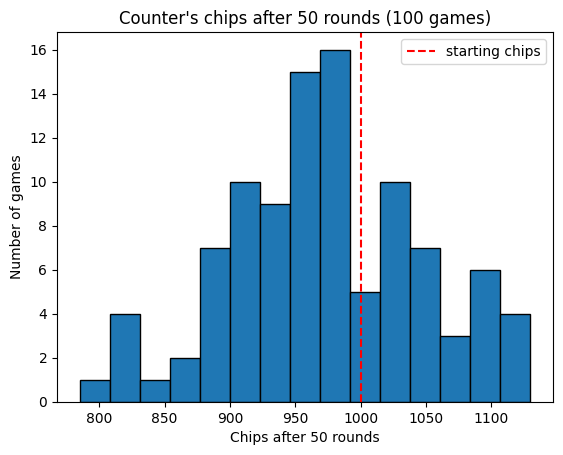

Average winnings per game: -28.3
Average winnings per round: -0.5660000000000001
Standard deviation of winnings per game: 74.6852655407269
Standard error of the average: 7.468526554072691

Probability of net winning: 0.32
Probability of net losing: 0.68
Probability of breaking even: 0.0


In [1]:
import random


class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        if self.rank == "A":
            return 11
        elif self.rank in ["J", "Q", "K"]:
            return 10
        else:
            return int(self.rank)

    def __str__(self):
        return self.rank + " of " + self.suit


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.shown_cards = []
        self.plastic_hit = False
        self.shuffle()

    def build(self):
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        suits = ["Spades", "Hearts", "Diamonds", "Clubs"]
        self.cards = []
        for i in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        self.build()
        random.shuffle(self.cards)
        spot = int(len(self.cards) * random.uniform(0.5, 0.85))
        self.cards.insert(spot, "PLASTIC")
        self.shown_cards = []
        self.plastic_hit = False

    def draw(self):
        card = self.cards.pop(0)
        if card == "PLASTIC":
            self.plastic_hit = True
            card = self.cards.pop(0)
        return card

    def show(self, card):
        self.shown_cards.append(card)

    def cards_left(self):
        count = 0
        for c in self.cards:
            if c != "PLASTIC":
                count += 1
        return count


class Hand:
    def __init__(self, bet=0):
        self.cards = []
        self.bet = bet
        self.is_split = False

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_soft(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return aces > 0

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_total() == 21 and not self.is_split

    def is_bust(self):
        return self.get_total() > 21

    def can_split(self):
        if len(self.cards) != 2:
            return False
        return self.cards[0].get_value() == self.cards[1].get_value()

    def __str__(self):
        names = []
        for card in self.cards:
            names.append(str(card))
        return ", ".join(names) + " (" + str(self.get_total()) + ")"


class Strategy:
    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class BasicStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class HiLoStrategy(Strategy):
    def __init__(self, flat_bet=10, threshold=0):
        self.flat_bet = flat_bet
        self.threshold = threshold

    def running_count(self, deck):
        count = 0
        for card in deck.shown_cards:
            if card.get_value() <= 6:
                count += 1
            elif card.get_value() >= 10:
                count -= 1
        return count

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        total = hand.get_total()
        if total < 12:
            return "hit"
        if total >= 17:
            return "stand"
        if self.running_count(deck) < self.threshold:
            return "hit"
        return "stand"


class MimicDealerStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        if hand.get_total() < 17:
            return "hit"
        return "stand"


class Player:
    def __init__(self, name, chips, strategy=None):
        self.name = name
        self.chips = chips
        self.hands = []
        self.strategy = strategy
        self.min_bet = 10

    def available_chips(self):
        total_bet = 0
        for hand in self.hands:
            total_bet += hand.bet
        return self.chips - total_bet

    def place_bet(self, deck):
        if self.strategy is None:
            return self.min_bet
        return self.strategy.get_bet(self.chips, deck)

    def choose_action(self, hand, upcard, deck):
        if self.strategy is None:
            return "stand"
        return self.strategy.get_action(hand, upcard, deck)

    def win(self, amount):
        self.chips += amount

    def lose(self, amount):
        self.chips -= amount

    def new_round(self):
        self.hands = []


class HumanPlayer(Player):
    def place_bet(self, deck):
        while True:
            answer = input(self.name + ", you have " + str(self.chips) + " chips. Bet (min " + str(self.min_bet) + "): ")
            try:
                bet = int(answer)
            except ValueError:
                print("Please enter a whole number")
                continue
            if bet < self.min_bet or bet > self.chips:
                print("Bet must be between", self.min_bet, "and", self.chips)
            else:
                return bet

    def choose_action(self, hand, upcard, deck):
        options = {"h": "hit", "s": "stand"}
        if len(hand.cards) == 2 and self.available_chips() >= hand.bet:
            options["d"] = "double"
            if hand.can_split() and len(self.hands) < 4:
                options["p"] = "split"
        print("Dealer shows:", upcard)
        print(self.name + ":", hand)
        prompt = ""
        for key in options:
            prompt += options[key] + " (" + key + ")  "
        while True:
            answer = input(prompt + ": ").strip().lower()
            if answer in options:
                return options[answer]
            print("Please choose one of the options")


class Dealer:
    def __init__(self):
        self.hand = Hand()

    def upcard(self):
        return self.hand.cards[0]

    def must_hit(self):
        return self.hand.get_total() < 17

    def new_round(self):
        self.hand = Hand()


class Game:
    def __init__(self, players, num_decks=6, min_bet=10):
        self.deck = Deck(num_decks)
        self.dealer = Dealer()
        self.players = players
        self.min_bet = min_bet
        self.verbose = True
        self.shuffles = 0
        for player in self.players:
            player.min_bet = min_bet

    def say(self, *words):
        if self.verbose:
            print(*words)

    def deal_card(self, hand, face_up=True):
        card = self.deck.draw()
        hand.add_card(card)
        if face_up:
            self.deck.show(card)
        return card

    def show_table(self, hide_dealer=True):
        self.say()
        if hide_dealer:
            self.say("Dealer shows:", self.dealer.upcard())
        else:
            self.say("Dealer:", self.dealer.hand)
        for player in self.players:
            for hand in player.hands:
                self.say(player.name + " (bet " + str(hand.bet) + "):", hand)
        self.say()

    def play_round(self):
        self.reshuffle_if_needed()
        self.dealer.new_round()
        playing = []
        for player in self.players:
            player.new_round()
            if player.chips >= self.min_bet:
                bet = player.place_bet(self.deck)
                player.hands.append(Hand(bet))
                playing.append(player)
        if len(playing) == 0:
            self.say("No players have enough chips to play")
            return
        self.deal_initial_cards()
        self.show_table()
        if self.dealer.hand.is_blackjack():
            self.deck.show(self.dealer.hand.cards[1])
            self.say("Dealer has blackjack!")
        else:
            for player in playing:
                self.play_player_turn(player)
            live = False
            for player in playing:
                for hand in player.hands:
                    if not hand.is_bust() and not hand.is_blackjack():
                        live = True
            if live:
                self.play_dealer_turn()
            else:
                self.deck.show(self.dealer.hand.cards[1])
        self.show_table(hide_dealer=False)
        self.settle_bets()

    def deal_initial_cards(self):
        for i in range(2):
            for player in self.players:
                for hand in player.hands:
                    self.deal_card(hand)
            self.deal_card(self.dealer.hand, face_up=(i == 0))

    def play_player_turn(self, player):
        i = 0
        while i < len(player.hands):
            hand = player.hands[i]
            while not hand.is_bust() and hand.get_total() < 21:
                action = player.choose_action(hand, self.dealer.upcard(), self.deck)
                if action == "hit":
                    self.deal_card(hand)
                    self.say(player.name + " hits:", hand)
                elif action == "double" and len(hand.cards) == 2 and player.available_chips() >= hand.bet:
                    hand.bet *= 2
                    self.deal_card(hand)
                    self.say(player.name + " doubles:", hand)
                    break
                elif action == "split" and hand.can_split() and player.available_chips() >= hand.bet and len(player.hands) < 4:
                    new_hand = Hand(hand.bet)
                    new_hand.add_card(hand.cards.pop())
                    hand.is_split = True
                    new_hand.is_split = True
                    self.deal_card(hand)
                    self.deal_card(new_hand)
                    player.hands.insert(i + 1, new_hand)
                    self.say(player.name + " splits:", hand)
                else:
                    break
            i += 1

    def play_dealer_turn(self):
        self.deck.show(self.dealer.hand.cards[1])
        while self.dealer.must_hit():
            self.deal_card(self.dealer.hand)

    def settle_bets(self):
        dealer_hand = self.dealer.hand
        for player in self.players:
            for hand in player.hands:
                if hand.is_bust():
                    player.lose(hand.bet)
                    result = "busts and loses " + str(hand.bet)
                elif hand.is_blackjack() and not dealer_hand.is_blackjack():
                    player.win(hand.bet * 1.5)
                    result = "has blackjack and wins " + str(hand.bet * 1.5)
                elif hand.is_blackjack():
                    result = "pushes"
                elif dealer_hand.is_blackjack():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet) + " to dealer blackjack"
                elif dealer_hand.is_bust():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet) + " (dealer busts)"
                elif hand.get_total() > dealer_hand.get_total():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet)
                elif hand.get_total() < dealer_hand.get_total():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet)
                else:
                    result = "pushes"
                self.say(player.name + ":", result, "- chips:", player.chips)

    def reshuffle_if_needed(self):
        if self.deck.plastic_hit:
            self.say("Plastic card was dealt, shuffling the shoe")
            self.deck.shuffle()
            self.shuffles += 1


class Simulation:
    def __init__(self, game, num_rounds):
        self.game = game
        self.num_rounds = num_rounds
        self.results = {}

    def run(self, num_rounds):
        pass

    def avg_winnings_per_hand(self, name):
        pass

    def compare_strategies(self):
        pass

    def print_report(self):
        pass


import random
random.seed(42)

ann = Player("Ann", 500, MimicDealerStrategy(10))
bob = Player("Bob", 500, MimicDealerStrategy(25))
cat = Player("Cat", 500, MimicDealerStrategy(50))
game = Game([ann, bob, cat])

for i in range(5):
    print("ROUND", i + 1)
    game.play_round()


for player in game.players:
    print(player.name, "has", player.chips, "chips")
print("Cards shown:", len(game.deck.shown_cards))
print("Cards left:", game.deck.cards_left())


random.seed(7)
ann = Player("Ann", 100000, MimicDealerStrategy(10))
bob = Player("Bob", 100000, MimicDealerStrategy(25))
cat = Player("Cat", 100000, MimicDealerStrategy(50))
big_game = Game([ann, bob, cat])
big_game.verbose = False

for i in range(2000):
    big_game.play_round()

print("Rounds played: 2000")
print("Times shuffled:", big_game.shuffles)
for player in big_game.players:
    print(player.name, "ended with", player.chips, "chips")
    print("average per round:", (player.chips - 100000) / 2000)


random.seed(5)
ann = Player("Ann", 500, MimicDealerStrategy(10))
dan = Player("Dan", 500, HiLoStrategy(10, 0))
count_game = Game([ann, dan])

for i in range(3):
    print("ROUND", i + 1)
    count_game.play_round()
    print("Running count:", dan.strategy.running_count(count_game.deck))
    print()


random.seed(11)
players = [Player("Mimic dealer", 1000000, MimicDealerStrategy(10))]
for t in [-4, -2, 0, 2, 4]:
    players.append(Player("Count, threshold " + str(t), 1000000, HiLoStrategy(10, t)))
test_game = Game(players)
test_game.verbose = False

rounds = 50000
for i in range(rounds):
    test_game.play_round()

print("Rounds played:", rounds)
for player in players:
    print(player.name, "- average winnings per round:", (player.chips - 1000000) / rounds)


random.seed(3)
start = 1000
counter = Player("Counter", start, HiLoStrategy(10, 0))
copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
scenario = Game([counter, copy1, copy2, copy3])
scenario.verbose = False

rounds_played = 0
while rounds_played < 50 and counter.chips >= scenario.min_bet:
    scenario.play_round()
    rounds_played += 1
    if rounds_played % 10 == 0:
        print("After round", rounds_played, "- Counter has", counter.chips, "chips")

print()
print("Rounds played:", rounds_played)
print("Counter winnings:", counter.chips - start)
for player in [copy1, copy2, copy3]:
    print(player.name, "winnings:", player.chips - start)


random.seed(99)
trials = 1000
total = 0
best = -100000
worst = 100000
ahead = 0
broke = 0

for t in range(trials):
    counter = Player("Counter", start, HiLoStrategy(10, 0))
    copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
    copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
    copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
    scenario = Game([counter, copy1, copy2, copy3])
    scenario.verbose = False

    rounds_played = 0
    while rounds_played < 50 and counter.chips >= scenario.min_bet:
        scenario.play_round()
        rounds_played += 1

    winnings = counter.chips - start
    total += winnings
    if winnings > best:
        best = winnings
    if winnings < worst:
        worst = winnings
    if winnings > 0:
        ahead += 1
    if counter.chips < scenario.min_bet:
        broke += 1

print("Scenarios played:", trials, "(50 rounds each)")
print("Average winnings for the counter:", total / trials)
print("Best:", best, "Worst:", worst)
print("Scenarios where the counter finished ahead:", ahead)
print("Scenarios where the counter ran out of chips:", broke)


import matplotlib.pyplot as plt
import numpy as np

random.seed(2024)
start = 1000
num_games = 100
final_chips = []

for i in range(num_games):
    counter = Player("Counter", start, HiLoStrategy(10, 0))
    copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
    copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
    copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
    table = Game([counter, copy1, copy2, copy3])
    table.verbose = False

    rounds_played = 0
    while rounds_played < 50 and counter.chips >= table.min_bet:
        table.play_round()
        rounds_played += 1

    final_chips.append(counter.chips)

plt.hist(final_chips, bins=15, edgecolor="black")
plt.axvline(start, color="red", linestyle="--", label="starting chips")
plt.xlabel("Chips after 50 rounds")
plt.ylabel("Number of games")
plt.title("Counter's chips after 50 rounds (100 games)")
plt.legend()
plt.show()


net = []
for chips in final_chips:
    net.append(chips - start)

average = np.mean(net)
std = np.std(net, ddof=1)

wins = 0
losses = 0
even = 0
for amount in net:
    if amount > 0:
        wins += 1
    elif amount < 0:
        losses += 1
    else:
        even += 1

print("Average winnings per game:", average)
print("Average winnings per round:", average / 50)
print("Standard deviation of winnings per game:", std)
print("Standard error of the average:", std / np.sqrt(num_games))
print()
print("Probability of net winning:", wins / num_games)
print("Probability of net losing:", losses / num_games)
print("Probability of breaking even:", even / num_games)

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

ROUND 1

Dealer shows: 8 of Hearts
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds (8)

Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades (11)
Cat hits: 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Dealer: 8 of Hearts, 4 of Clubs, K of Diamonds (22)
Ann (bet 10): 7 of Spades, 10 of Clubs (17)
Bob (bet 25): Q of Spades, K of Hearts (20)
Cat (bet 50): 4 of Spades, 4 of Diamonds, 3 of Spades, K of Spades (21)

Ann: wins 10 (dealer busts) - chips: 510
Bob: wins 25 (dealer busts) - chips: 525
Cat: wins 50 (dealer busts) - chips: 550
ROUND 2

Dealer shows: 6 of Diamonds
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 of Diamonds (16)
Cat (bet 50): 10 of Clubs, Q of Clubs (20)

Bob hits: 8 of Spades, 8 of Diamonds, 4 of Diamonds (20)

Dealer: 6 of Diamonds, 2 of Spades, 3 of Spades, 9 of Hearts (20)
Ann (bet 10): 8 of Clubs, 9 of Diamonds (17)
Bob (bet 25): 8 of Spades, 8 o

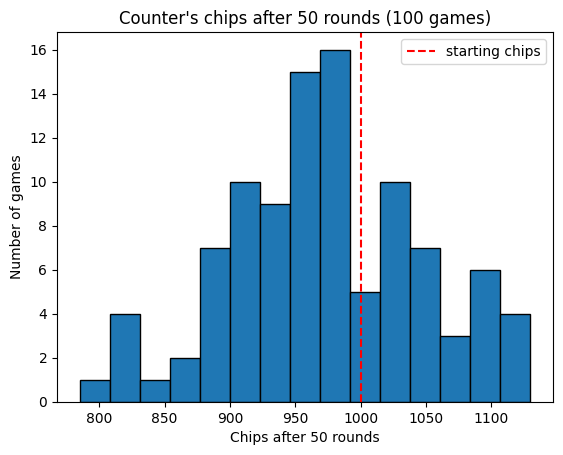

Average winnings per game: -28.3
Average winnings per round: -0.5660000000000001
Standard deviation of winnings per game: 74.6852655407269
Standard error of the average: 7.468526554072691

Probability of net winning: 0.32
Probability of net losing: 0.68
Probability of breaking even: 0.0
threshold  avg/round  std/game  P(win)  P(lose)
-6 	 -0.909 	 77.2 	 0.26 	 0.74
-4 	 -0.831 	 61.9 	 0.26 	 0.71
-2 	 -0.484 	 59.2 	 0.31 	 0.68
0 	 -0.786 	 61.9 	 0.27 	 0.72
2 	 -0.546 	 65.6 	 0.34 	 0.64
4 	 -0.459 	 60.0 	 0.33 	 0.67
6 	 -0.4 	 68.6 	 0.37 	 0.62
8 	 -0.648 	 70.5 	 0.24 	 0.73


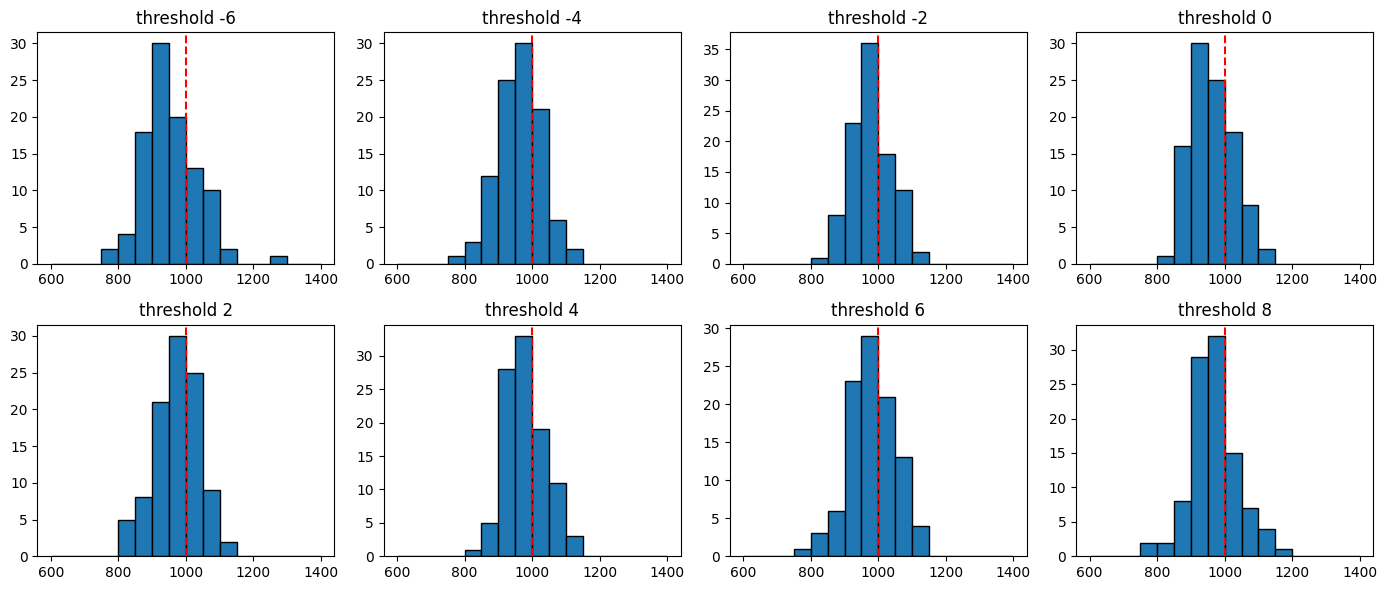

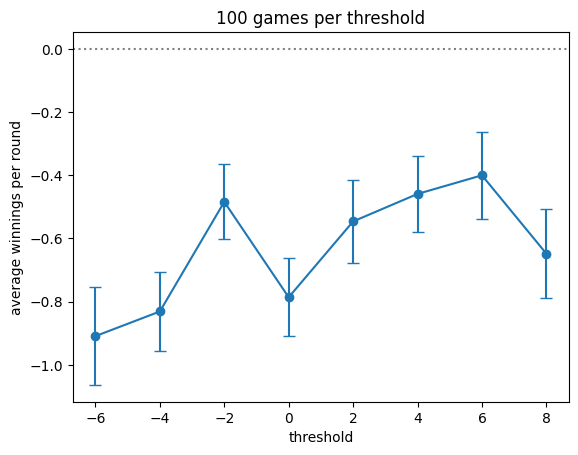

threshold  avg/round  +/-  std/game  P(win)  P(lose)
-6 	 -0.763 	 0.032 	 71.7 	 0.294 	 0.685
-4 	 -0.693 	 0.031 	 69.4 	 0.2915 	 0.6825
-2 	 -0.667 	 0.031 	 69.7 	 0.307 	 0.673
0 	 -0.606 	 0.031 	 68.2 	 0.31 	 0.6635
2 	 -0.61 	 0.031 	 69.1 	 0.306 	 0.66
4 	 -0.563 	 0.03 	 67.8 	 0.321 	 0.656
6 	 -0.556 	 0.03 	 68.0 	 0.3295 	 0.6455
8 	 -0.499 	 0.031 	 69.3 	 0.3485 	 0.625
always hit below 17 	 -0.584 	 0.03 	 68.0 	 0.316 	 0.6615

Best threshold: 8 with -0.499 per round


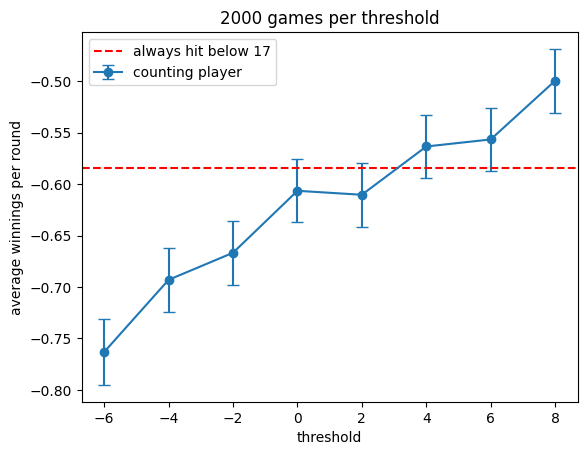

In [1]:
import random


class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        if self.rank == "A":
            return 11
        elif self.rank in ["J", "Q", "K"]:
            return 10
        else:
            return int(self.rank)

    def __str__(self):
        return self.rank + " of " + self.suit


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.shown_cards = []
        self.plastic_hit = False
        self.shuffle()

    def build(self):
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
        suits = ["Spades", "Hearts", "Diamonds", "Clubs"]
        self.cards = []
        for i in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        self.build()
        random.shuffle(self.cards)
        spot = int(len(self.cards) * random.uniform(0.5, 0.85))
        self.cards.insert(spot, "PLASTIC")
        self.shown_cards = []
        self.plastic_hit = False

    def draw(self):
        card = self.cards.pop(0)
        if card == "PLASTIC":
            self.plastic_hit = True
            card = self.cards.pop(0)
        return card

    def show(self, card):
        self.shown_cards.append(card)

    def cards_left(self):
        count = 0
        for c in self.cards:
            if c != "PLASTIC":
                count += 1
        return count


class Hand:
    def __init__(self, bet=0):
        self.cards = []
        self.bet = bet
        self.is_split = False

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_soft(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return aces > 0

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_total() == 21 and not self.is_split

    def is_bust(self):
        return self.get_total() > 21

    def can_split(self):
        if len(self.cards) != 2:
            return False
        return self.cards[0].get_value() == self.cards[1].get_value()

    def __str__(self):
        names = []
        for card in self.cards:
            names.append(str(card))
        return ", ".join(names) + " (" + str(self.get_total()) + ")"


class Strategy:
    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class BasicStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        pass

    def get_action(self, hand, upcard, deck):
        pass


class HiLoStrategy(Strategy):
    def __init__(self, flat_bet=10, threshold=0):
        self.flat_bet = flat_bet
        self.threshold = threshold

    def running_count(self, deck):
        count = 0
        for card in deck.shown_cards:
            if card.get_value() <= 6:
                count += 1
            elif card.get_value() >= 10:
                count -= 1
        return count

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        total = hand.get_total()
        if total < 12:
            return "hit"
        if total >= 17:
            return "stand"
        if self.running_count(deck) < self.threshold:
            return "hit"
        return "stand"


class MimicDealerStrategy(Strategy):
    def __init__(self, flat_bet=10):
        self.flat_bet = flat_bet

    def get_bet(self, chips, deck):
        return min(self.flat_bet, chips)

    def get_action(self, hand, upcard, deck):
        if hand.get_total() < 17:
            return "hit"
        return "stand"


class Player:
    def __init__(self, name, chips, strategy=None):
        self.name = name
        self.chips = chips
        self.hands = []
        self.strategy = strategy
        self.min_bet = 10

    def available_chips(self):
        total_bet = 0
        for hand in self.hands:
            total_bet += hand.bet
        return self.chips - total_bet

    def place_bet(self, deck):
        if self.strategy is None:
            return self.min_bet
        return self.strategy.get_bet(self.chips, deck)

    def choose_action(self, hand, upcard, deck):
        if self.strategy is None:
            return "stand"
        return self.strategy.get_action(hand, upcard, deck)

    def win(self, amount):
        self.chips += amount

    def lose(self, amount):
        self.chips -= amount

    def new_round(self):
        self.hands = []


class HumanPlayer(Player):
    def place_bet(self, deck):
        while True:
            answer = input(self.name + ", you have " + str(self.chips) + " chips. Bet (min " + str(self.min_bet) + "): ")
            try:
                bet = int(answer)
            except ValueError:
                print("Please enter a whole number")
                continue
            if bet < self.min_bet or bet > self.chips:
                print("Bet must be between", self.min_bet, "and", self.chips)
            else:
                return bet

    def choose_action(self, hand, upcard, deck):
        options = {"h": "hit", "s": "stand"}
        if len(hand.cards) == 2 and self.available_chips() >= hand.bet:
            options["d"] = "double"
            if hand.can_split() and len(self.hands) < 4:
                options["p"] = "split"
        print("Dealer shows:", upcard)
        print(self.name + ":", hand)
        prompt = ""
        for key in options:
            prompt += options[key] + " (" + key + ")  "
        while True:
            answer = input(prompt + ": ").strip().lower()
            if answer in options:
                return options[answer]
            print("Please choose one of the options")


class Dealer:
    def __init__(self):
        self.hand = Hand()

    def upcard(self):
        return self.hand.cards[0]

    def must_hit(self):
        return self.hand.get_total() < 17

    def new_round(self):
        self.hand = Hand()


class Game:
    def __init__(self, players, num_decks=6, min_bet=10):
        self.deck = Deck(num_decks)
        self.dealer = Dealer()
        self.players = players
        self.min_bet = min_bet
        self.verbose = True
        self.shuffles = 0
        for player in self.players:
            player.min_bet = min_bet

    def say(self, *words):
        if self.verbose:
            print(*words)

    def deal_card(self, hand, face_up=True):
        card = self.deck.draw()
        hand.add_card(card)
        if face_up:
            self.deck.show(card)
        return card

    def show_table(self, hide_dealer=True):
        self.say()
        if hide_dealer:
            self.say("Dealer shows:", self.dealer.upcard())
        else:
            self.say("Dealer:", self.dealer.hand)
        for player in self.players:
            for hand in player.hands:
                self.say(player.name + " (bet " + str(hand.bet) + "):", hand)
        self.say()

    def play_round(self):
        self.reshuffle_if_needed()
        self.dealer.new_round()
        playing = []
        for player in self.players:
            player.new_round()
            if player.chips >= self.min_bet:
                bet = player.place_bet(self.deck)
                player.hands.append(Hand(bet))
                playing.append(player)
        if len(playing) == 0:
            self.say("No players have enough chips to play")
            return
        self.deal_initial_cards()
        self.show_table()
        if self.dealer.hand.is_blackjack():
            self.deck.show(self.dealer.hand.cards[1])
            self.say("Dealer has blackjack!")
        else:
            for player in playing:
                self.play_player_turn(player)
            live = False
            for player in playing:
                for hand in player.hands:
                    if not hand.is_bust() and not hand.is_blackjack():
                        live = True
            if live:
                self.play_dealer_turn()
            else:
                self.deck.show(self.dealer.hand.cards[1])
        self.show_table(hide_dealer=False)
        self.settle_bets()

    def deal_initial_cards(self):
        for i in range(2):
            for player in self.players:
                for hand in player.hands:
                    self.deal_card(hand)
            self.deal_card(self.dealer.hand, face_up=(i == 0))

    def play_player_turn(self, player):
        i = 0
        while i < len(player.hands):
            hand = player.hands[i]
            while not hand.is_bust() and hand.get_total() < 21:
                action = player.choose_action(hand, self.dealer.upcard(), self.deck)
                if action == "hit":
                    self.deal_card(hand)
                    self.say(player.name + " hits:", hand)
                elif action == "double" and len(hand.cards) == 2 and player.available_chips() >= hand.bet:
                    hand.bet *= 2
                    self.deal_card(hand)
                    self.say(player.name + " doubles:", hand)
                    break
                elif action == "split" and hand.can_split() and player.available_chips() >= hand.bet and len(player.hands) < 4:
                    new_hand = Hand(hand.bet)
                    new_hand.add_card(hand.cards.pop())
                    hand.is_split = True
                    new_hand.is_split = True
                    self.deal_card(hand)
                    self.deal_card(new_hand)
                    player.hands.insert(i + 1, new_hand)
                    self.say(player.name + " splits:", hand)
                else:
                    break
            i += 1

    def play_dealer_turn(self):
        self.deck.show(self.dealer.hand.cards[1])
        while self.dealer.must_hit():
            self.deal_card(self.dealer.hand)

    def settle_bets(self):
        dealer_hand = self.dealer.hand
        for player in self.players:
            for hand in player.hands:
                if hand.is_bust():
                    player.lose(hand.bet)
                    result = "busts and loses " + str(hand.bet)
                elif hand.is_blackjack() and not dealer_hand.is_blackjack():
                    player.win(hand.bet * 1.5)
                    result = "has blackjack and wins " + str(hand.bet * 1.5)
                elif hand.is_blackjack():
                    result = "pushes"
                elif dealer_hand.is_blackjack():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet) + " to dealer blackjack"
                elif dealer_hand.is_bust():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet) + " (dealer busts)"
                elif hand.get_total() > dealer_hand.get_total():
                    player.win(hand.bet)
                    result = "wins " + str(hand.bet)
                elif hand.get_total() < dealer_hand.get_total():
                    player.lose(hand.bet)
                    result = "loses " + str(hand.bet)
                else:
                    result = "pushes"
                self.say(player.name + ":", result, "- chips:", player.chips)

    def reshuffle_if_needed(self):
        if self.deck.plastic_hit:
            self.say("Plastic card was dealt, shuffling the shoe")
            self.deck.shuffle()
            self.shuffles += 1


class Simulation:
    def __init__(self, game, num_rounds):
        self.game = game
        self.num_rounds = num_rounds
        self.results = {}

    def run(self, num_rounds):
        pass

    def avg_winnings_per_hand(self, name):
        pass

    def compare_strategies(self):
        pass

    def print_report(self):
        pass


import random
random.seed(42)

ann = Player("Ann", 500, MimicDealerStrategy(10))
bob = Player("Bob", 500, MimicDealerStrategy(25))
cat = Player("Cat", 500, MimicDealerStrategy(50))
game = Game([ann, bob, cat])

for i in range(5):
    print("ROUND", i + 1)
    game.play_round()


for player in game.players:
    print(player.name, "has", player.chips, "chips")
print("Cards shown:", len(game.deck.shown_cards))
print("Cards left:", game.deck.cards_left())


random.seed(7)
ann = Player("Ann", 100000, MimicDealerStrategy(10))
bob = Player("Bob", 100000, MimicDealerStrategy(25))
cat = Player("Cat", 100000, MimicDealerStrategy(50))
big_game = Game([ann, bob, cat])
big_game.verbose = False

for i in range(2000):
    big_game.play_round()

print("Rounds played: 2000")
print("Times shuffled:", big_game.shuffles)
for player in big_game.players:
    print(player.name, "ended with", player.chips, "chips")
    print("average per round:", (player.chips - 100000) / 2000)


random.seed(5)
ann = Player("Ann", 500, MimicDealerStrategy(10))
dan = Player("Dan", 500, HiLoStrategy(10, 0))
count_game = Game([ann, dan])

for i in range(3):
    print("ROUND", i + 1)
    count_game.play_round()
    print("Running count:", dan.strategy.running_count(count_game.deck))
    print()


random.seed(11)
players = [Player("Mimic dealer", 1000000, MimicDealerStrategy(10))]
for t in [-4, -2, 0, 2, 4]:
    players.append(Player("Count, threshold " + str(t), 1000000, HiLoStrategy(10, t)))
test_game = Game(players)
test_game.verbose = False

rounds = 50000
for i in range(rounds):
    test_game.play_round()

print("Rounds played:", rounds)
for player in players:
    print(player.name, "- average winnings per round:", (player.chips - 1000000) / rounds)


random.seed(3)
start = 1000
counter = Player("Counter", start, HiLoStrategy(10, 0))
copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
scenario = Game([counter, copy1, copy2, copy3])
scenario.verbose = False

rounds_played = 0
while rounds_played < 50 and counter.chips >= scenario.min_bet:
    scenario.play_round()
    rounds_played += 1
    if rounds_played % 10 == 0:
        print("After round", rounds_played, "- Counter has", counter.chips, "chips")

print()
print("Rounds played:", rounds_played)
print("Counter winnings:", counter.chips - start)
for player in [copy1, copy2, copy3]:
    print(player.name, "winnings:", player.chips - start)


random.seed(99)
trials = 1000
total = 0
best = -100000
worst = 100000
ahead = 0
broke = 0

for t in range(trials):
    counter = Player("Counter", start, HiLoStrategy(10, 0))
    copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
    copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
    copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
    scenario = Game([counter, copy1, copy2, copy3])
    scenario.verbose = False

    rounds_played = 0
    while rounds_played < 50 and counter.chips >= scenario.min_bet:
        scenario.play_round()
        rounds_played += 1

    winnings = counter.chips - start
    total += winnings
    if winnings > best:
        best = winnings
    if winnings < worst:
        worst = winnings
    if winnings > 0:
        ahead += 1
    if counter.chips < scenario.min_bet:
        broke += 1

print("Scenarios played:", trials, "(50 rounds each)")
print("Average winnings for the counter:", total / trials)
print("Best:", best, "Worst:", worst)
print("Scenarios where the counter finished ahead:", ahead)
print("Scenarios where the counter ran out of chips:", broke)


import matplotlib.pyplot as plt
import numpy as np

random.seed(2024)
start = 1000
num_games = 100
final_chips = []

for i in range(num_games):
    counter = Player("Counter", start, HiLoStrategy(10, 0))
    copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
    copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
    copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
    table = Game([counter, copy1, copy2, copy3])
    table.verbose = False

    rounds_played = 0
    while rounds_played < 50 and counter.chips >= table.min_bet:
        table.play_round()
        rounds_played += 1

    final_chips.append(counter.chips)

plt.hist(final_chips, bins=15, edgecolor="black")
plt.axvline(start, color="red", linestyle="--", label="starting chips")
plt.xlabel("Chips after 50 rounds")
plt.ylabel("Number of games")
plt.title("Counter's chips after 50 rounds (100 games)")
plt.legend()
plt.show()


net = []
for chips in final_chips:
    net.append(chips - start)

average = np.mean(net)
std = np.std(net, ddof=1)

wins = 0
losses = 0
even = 0
for amount in net:
    if amount > 0:
        wins += 1
    elif amount < 0:
        losses += 1
    else:
        even += 1

print("Average winnings per game:", average)
print("Average winnings per round:", average / 50)
print("Standard deviation of winnings per game:", std)
print("Standard error of the average:", std / np.sqrt(num_games))
print()
print("Probability of net winning:", wins / num_games)
print("Probability of net losing:", losses / num_games)
print("Probability of breaking even:", even / num_games)


import numpy as np
import matplotlib.pyplot as plt

start = 1000

def play_games(threshold, num_games):
    results = []
    for i in range(num_games):
        counter = Player("Counter", start, HiLoStrategy(10, threshold))
        copy1 = Player("Copycat 1", start, MimicDealerStrategy(10))
        copy2 = Player("Copycat 2", start, MimicDealerStrategy(10))
        copy3 = Player("Copycat 3", start, MimicDealerStrategy(10))
        table = Game([counter, copy1, copy2, copy3])
        table.verbose = False

        rounds_played = 0
        while rounds_played < 50 and counter.chips >= table.min_bet:
            table.play_round()
            rounds_played += 1

        results.append(counter.chips)
    return results

def get_stats(final_chips):
    net = []
    for chips in final_chips:
        net.append(chips - start)

    average = np.mean(net) / 50
    std = np.std(net, ddof=1)
    error = std / np.sqrt(len(net)) / 50

    wins = 0
    losses = 0
    for amount in net:
        if amount > 0:
            wins += 1
        elif amount < 0:
            losses += 1
    return average, std, error, wins / len(net), losses / len(net)


thresholds = [-6, -4, -2, 0, 2, 4, 6, 8]
random.seed(100)
scan_results = {}

print("threshold  avg/round  std/game  P(win)  P(lose)")
for threshold in thresholds:
    scan_results[threshold] = play_games(threshold, 100)
    average, std, error, p_win, p_lose = get_stats(scan_results[threshold])
    print(threshold, "\t", round(average, 3), "\t", round(std, 1), "\t", p_win, "\t", p_lose)


plt.figure(figsize=(14, 6))
for i in range(len(thresholds)):
    plt.subplot(2, 4, i + 1)
    plt.hist(scan_results[thresholds[i]], bins=16, range=(600, 1400), edgecolor="black")
    plt.axvline(start, color="red", linestyle="--")
    plt.title("threshold " + str(thresholds[i]))
plt.tight_layout()
plt.show()


averages = []
errors = []
for threshold in thresholds:
    average, std, error, p_win, p_lose = get_stats(scan_results[threshold])
    averages.append(average)
    errors.append(error)

plt.errorbar(thresholds, averages, yerr=errors, marker="o", capsize=4)
plt.axhline(0, color="gray", linestyle=":")
plt.xlabel("threshold")
plt.ylabel("average winnings per round")
plt.title("100 games per threshold")
plt.show()


random.seed(200)
big_games = 2000
big_averages = []
big_errors = []

print("threshold  avg/round  +/-  std/game  P(win)  P(lose)")
for threshold in thresholds:
    results = play_games(threshold, big_games)
    average, std, error, p_win, p_lose = get_stats(results)
    big_averages.append(average)
    big_errors.append(error)
    print(threshold, "\t", round(average, 3), "\t", round(error, 3), "\t", round(std, 1), "\t", p_win, "\t", p_lose)

no_count = play_games(100, big_games)
ref_average, ref_std, ref_error, ref_win, ref_lose = get_stats(no_count)
print("always hit below 17", "\t", round(ref_average, 3), "\t", round(ref_error, 3), "\t", round(ref_std, 1), "\t", ref_win, "\t", ref_lose)

best = 0
for i in range(len(thresholds)):
    if big_averages[i] > big_averages[best]:
        best = i
print()
print("Best threshold:", thresholds[best], "with", round(big_averages[best], 3), "per round")

plt.errorbar(thresholds, big_averages, yerr=big_errors, marker="o", capsize=4, label="counting player")
plt.axhline(ref_average, color="red", linestyle="--", label="always hit below 17")
plt.xlabel("threshold")
plt.ylabel("average winnings per round")
plt.title("2000 games per threshold")
plt.legend()
plt.show()

In [3]:
%pip install matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [ ]:

import random

def create_deck():
    cards = [2, 3, 4, 5, 6, 7, 8, 9] * 24 + [10] * 96 + [11] * 24
    random.shuffle(cards)
    return cards

def hand_value(hand):
    total = sum(hand)
    aces = hand.count(11)

    while total > 21 and aces > 0:
        total -= 10
        aces -= 1

    return total

def strategy_a(hand, dealer_card):
    return hand_value(hand) < 17

def strategy_b(hand, dealer_card):
    total = hand_value(hand)

    if total <= 11:
        return True

    if 12 <= total <= 16:
        return dealer_card >= 7

    return False

def play_round(strategy):
    deck = create_deck()

    player = [deck.pop(), deck.pop()]
    dealer = [deck.pop(), deck.pop()]
    dealer_card = dealer[0]

    while strategy(player, dealer_card):
        player.append(deck.pop())

        if hand_value(player) > 21:
            return -1

    while hand_value(dealer) < 17:
        dealer.append(deck.pop())

    player_total = hand_value(player)
    dealer_total = hand_value(dealer)

    if dealer_total > 21 or player_total > dealer_total:
        return 1
    elif player_total < dealer_total:
        return -1
    else:
        return 0

def simulate(strategy, n=100000):
    results = [play_round(strategy) for _ in range(n)]

    wins = results.count(1)
    losses = results.count(-1)
    pushes = results.count(0)
    profit = sum(results)

    return {
        "Wins": wins,
        "Losses": losses,
        "Pushes": pushes,
        "Total Profit": profit,
        "Average Profit per Hand": profit / n,
        "Win Percentage": wins / n * 100
    }

random.seed(42)

a = simulate(strategy_a)
b = simulate(strategy_b)

print("Strategy A")
print(a)

print("\nStrategy B")
print(b)

print("\nDifference in Average Profit")
print(b["Average Profit per Hand"] - a["Average Profit per Hand"])